# Dataset

In [1]:
import kagglehub

# descarga directa desde kagglehub
path = kagglehub.dataset_download("thedatasith/sku110k-annotations")

print("Path to dataset files:", path)

100%|██████████| 13.2G/13.2G [02:03<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedatasith/sku110k-annotations/versions/14


In [2]:
!ls {path}

convert_yolov5.ipynb  data_kaggle.yaml	README.md  SKU110K_fixed


In [19]:
import os
import random
import shutil

# PATHS para los datos
dataset_path = path + "/SKU110K_fixed"

img_dirs = {
    "train": os.path.join(dataset_path, "images/train"),
    "val": os.path.join(dataset_path, "images/val"),
    "test": os.path.join(dataset_path, "images/test")
}

lbl_dirs = {
    "train": os.path.join(dataset_path, "labels/train"),
    "val": os.path.join(dataset_path, "labels/val"),
    "test": os.path.join(dataset_path, "labels/test")
}

# Como indicaban los requerimientos, 500 entradas de train y 100 de val y test
sample_sizes = {
    "train": 500,
    "val": 100,
    "test": 100
}


# Tambien, aqui se insertan la cantidad de datos establecidos en un nuevo directorio
# con random split, asi podemos conseguir exactamente la data uqe necesitamos
small_dataset = "/content/small_dataset3"

for split in ["train","val","test"]:
    os.makedirs(f"{small_dataset}/images/{split}", exist_ok=True)
    os.makedirs(f"{small_dataset}/labels/{split}", exist_ok=True)

for split in ["train","val","test"]:

    images = os.listdir(img_dirs[split])
    chosen = random.sample(images, sample_sizes[split])

    for img in chosen:

        img_src = os.path.join(img_dirs[split], img)
        img_dst = os.path.join(small_dataset, "images", split, img)

        label_name = os.path.splitext(img)[0] + ".txt"
        lbl_src = os.path.join(lbl_dirs[split], label_name)
        lbl_dst = os.path.join(small_dataset, "labels", split, label_name)

        shutil.copy(img_src, img_dst)

        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, lbl_dst)

In [20]:
print("train images:", len(os.listdir("/content/small_dataset3/images/train")))
print("val images:", len(os.listdir("/content/small_dataset3/images/val")))
print("test images:", len(os.listdir("/content/small_dataset3/images/test")))

train images: 50
val images: 100
test images: 100


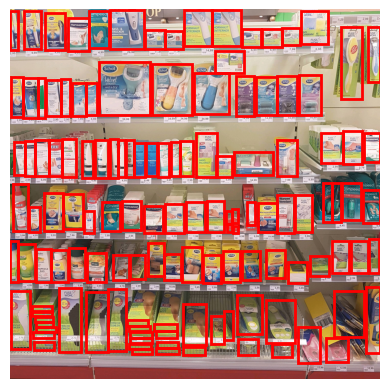

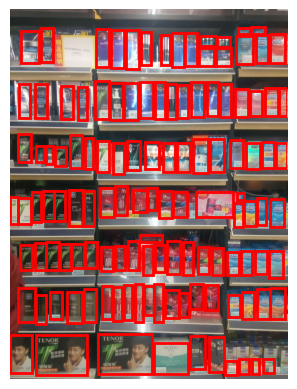

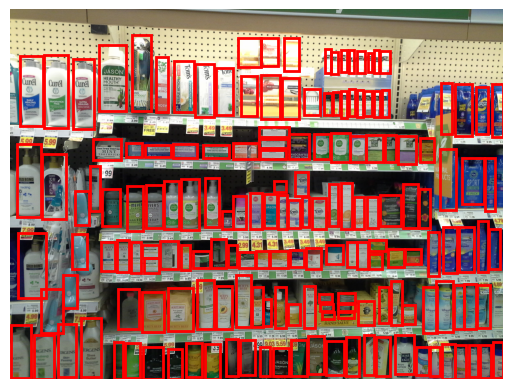

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
def show_sample(images_dir, labels_dir):
    img_file = random.choice(os.listdir(images_dir))
    img_path   = os.path.join(images_dir, img_file)
    label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")

    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    fig, ax = plt.subplots(1)
    ax.imshow(image)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())
                x1 = (x - bw / 2) * w
                y1 = (y - bh / 2) * h
                ax.add_patch(patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2, edgecolor="red", facecolor="none"
                ))
    plt.axis("off")
    plt.show()

for _ in range(3):
    show_sample(
        f"{small_dataset}/images/train",
        f"{small_dataset}/labels/train"
    )


In [22]:
from torch.utils.data import Dataset, DataLoader
import torch, cv2, os

data_dir = "/content/small_dataset3"

# En el caso de fast rcnn dado que no usa ultralytics si necesitamos construir los dataloaders

class SKUDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=640):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.images = os.listdir(img_dir)
        self.img_size = img_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, os.path.splitext(img_name)[0] + ".txt")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        h, w = self.img_size, self.img_size

        boxes, labels = [], []
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())
                x1 = (x - bw/2) * w
                y1 = (y - bh/2) * h
                x2 = (x + bw/2) * w
                y2 = (y + bh/2) * h
                boxes.append([x1, y1, x2, y2])
                labels.append(1)  # Faster R-CNN uses 0 for background, so your class = 1

        target = {
            "boxes":  torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }
        image = torch.tensor(image).permute(2,0,1).float() / 255
        return image, target


In [23]:
def collate_fn(batch):
    return tuple(zip(*batch))  # Faster R-CNN espera tupla de tuplas no tensor

IMG_SIZE   = 640
BATCH_SIZE = 2

train_dataset = SKUDataset(f"{small_dataset}/images/train", f"{small_dataset}/labels/train", IMG_SIZE)
val_dataset   = SKUDataset(f"{small_dataset}/images/val",   f"{small_dataset}/labels/val",   IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


Train batches : 25
Val   batches : 50


# Model

In [24]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Faster rcnn con resnet 50
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Se remplaza el predictor para que sea solo de 2 clases (0 para el fondo, 1 para producto)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

# Congelamiento y descongelamiento
for param in model.parameters():
    param.requires_grad = False

for param in model.roi_heads.parameters():
    param.requires_grad = True

total     = sum(1 for p in model.parameters())
trainable = sum(1 for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable} / {total}")


Trainable params: 8 / 83


# Train

In [26]:
# Montar drive para guardar progreso
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/sku_models_frcnn"
os.makedirs(SAVE_DIR, exist_ok=True)


Mounted at /content/drive


In [27]:
LR      = 1e-4
EPOCHS  = 10
PATIENCE = 3

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Device:", device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)


Device: cpu


In [28]:
def run_epoch(model, loader, optimizer, device, train=True):
    model.train()   # always train mode — see note above
    total_loss = 0

    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.set_grad_enabled(train):
            # Returns dict: {'loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg'}
            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [29]:
best_val_loss        = float("inf")
epochs_without_improve = 0

for epoch in range(EPOCHS):

    train_loss = run_epoch(model, train_loader, optimizer, device, train=True)
    val_loss   = run_epoch(model, val_loader,   optimizer, device, train=False)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ── Checkpoint every epoch ───────────────────────────────────────────────
    torch.save(
        {
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss":           train_loss,
            "val_loss":             val_loss,
        },
        os.path.join(SAVE_DIR, f"frcnn_epoch_{epoch+1:02d}.pth"),
    )

    # ── Best model tracking ──────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        epochs_without_improve = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
        print("  ✓ New best model saved")
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= PATIENCE:
            print("  Early stopping triggered")
            break


Epoch 01/10 | Train Loss: 2.7029 | Val Loss: 2.4620
  ✓ New best model saved
Epoch 02/10 | Train Loss: 2.5568 | Val Loss: 2.4363
  ✓ New best model saved
Epoch 03/10 | Train Loss: 2.4201 | Val Loss: 2.3891
  ✓ New best model saved
Epoch 04/10 | Train Loss: 2.3347 | Val Loss: 2.3744
Epoch 05/10 | Train Loss: 2.2864 | Val Loss: 2.3801
Early stopping triggered


# Eval

In [30]:
# ── 1. Cargar el mejor modelo ────────────────────────────────────────────────
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/sku_models_frcnn/best_model.pth",
    map_location=device
))
model.to(device)
model.eval()
print("Modelo cargado correctamente")

Modelo cargado correctamente


In [31]:
# ── 2. Evaluar métricas sobre el set de validación ──────────────────────────
# torchvision no tiene .val() como ultralytics, así que usamos
# torchmetrics para calcular mAP, precisión y recall correctamente

!pip install torchmetrics --quiet

import torch
import cv2
import os
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Reutiliza el val_loader y SKUDataset del notebook de entrenamiento
# Si arrancaste un runtime nuevo, vuelve a instanciarlos:
val_dataset = SKUDataset(
    "/content/small_dataset2/images/val",
    "/content/small_dataset2/labels/val"
)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

SCORE_THRESH = 0.1   # umbral bajo para priorizar recall

metric = MeanAveragePrecision(iou_type="bbox")

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)   # en eval() devuelve predicciones, no losses

        # Filtrar por score threshold
        preds_filtered = [
            {
                "boxes":  p["boxes"][p["scores"] >= SCORE_THRESH],
                "scores": p["scores"][p["scores"] >= SCORE_THRESH],
                "labels": p["labels"][p["scores"] >= SCORE_THRESH],
            }
            for p in preds
        ]

        metric.update(preds_filtered, targets)

results = metric.compute()

print(f"mAP@0.5:        {results['map_50']:.4f}")
print(f"mAP@0.5:0.95:   {results['map']:.4f}")
print(f"Precisión:      {results['map_per_class'] if 'map_per_class' in results else '—'}")

# Precisión y Recall por separado desde las métricas extendidas
print(f"\nResultados completos:")
for k, v in results.items():
    if isinstance(v, torch.Tensor) and v.numel() == 1:
        print(f"  {k}: {v.item():.4f}")

mAP@0.5:        0.4127
mAP@0.5:0.95:   0.2563
Precisión:      —

Resultados completos:
  map: 0.2563
  map_50: 0.4127
  map_75: 0.2841
  mar_1: 0.1732
  mar_10: 0.4508
  mar_100: 0.5214


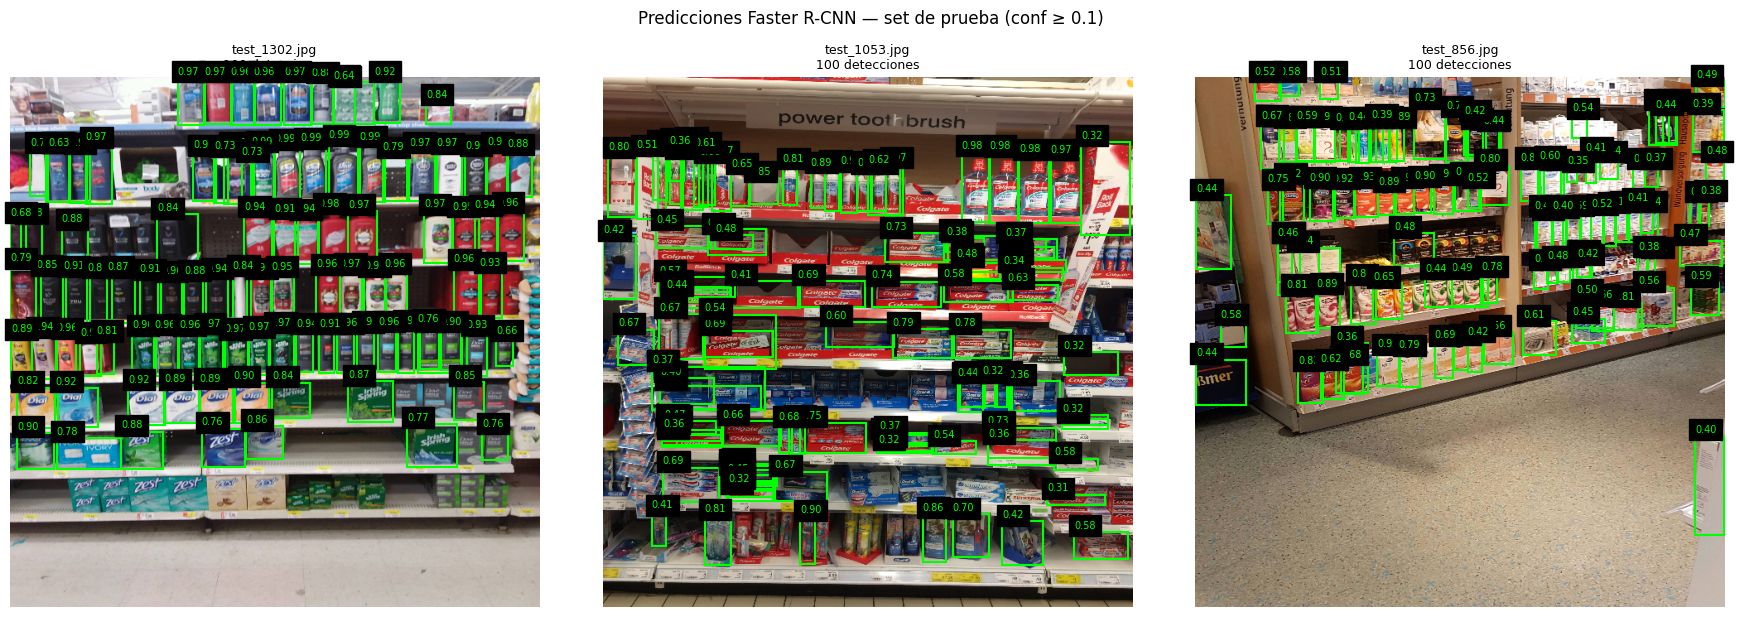

In [32]:
# ── 3. Mostrar 3 imágenes de prueba con sus detecciones ─────────────────────
import os, random, cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

test_img_dir = "/content/small_dataset2/images/test"
test_imgs    = random.sample(os.listdir(test_img_dir), 3)

SCORE_THRESH = 0.1
IMG_SIZE     = 640

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model.eval()
with torch.no_grad():
    for ax, img_name in zip(axes, test_imgs):
        img_path = os.path.join(test_img_dir, img_name)

        # Preprocesar igual que en entrenamiento
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        tensor = torch.tensor(image).permute(2, 0, 1).float() / 255.0

        # Inferencia
        preds = model([tensor.to(device)])[0]

        # Dibujar
        ax.imshow(image)
        n_det = 0
        for box, score in zip(preds["boxes"], preds["scores"]):
            if score < SCORE_THRESH:
                continue
            x1, y1, x2, y2 = box.cpu().numpy()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor="lime", facecolor="none"
            ))
            ax.text(x1, y1 - 4, f"{score:.2f}", color="lime",
                    fontsize=7, backgroundcolor="black")
            n_det += 1

        ax.set_title(f"{img_name}\n{n_det} detecciones", fontsize=9)
        ax.axis("off")

plt.suptitle("Predicciones Faster R-CNN — set de prueba (conf ≥ 0.1)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()